# Load Data

In [1]:
import pandas as pd
df = pd.read_excel("/content/Data baru.xlsx")
df.head()

,Bandara/pelabuhan,Year,Month,Wisatawan
0,Ngurah Rai,2020,1,533392
1,Ngurah Rai,2020,2,358929
2,Ngurah Rai,2020,3,166388
3,Ngurah Rai,2020,4,273
4,Ngurah Rai,2020,5,34


In [2]:
df

,Bandara/pelabuhan,Year,Month,Wisatawan
0,Ngurah Rai,2020,1,533392
1,Ngurah Rai,2020,2,358929
2,Ngurah Rai,2020,3,166388
3,Ngurah Rai,2020,4,273
4,Ngurah Rai,2020,5,34
...,...,...,...,...
1255,Nanga Badau,2024,8,892
1256,Nanga Badau,2024,9,1116
1257,Nanga Badau,2024,10,742
1258,Nanga Badau,2024,11,732


# Data Preprocessing

In [3]:
df.describe()

,Year,Month,Wisatawan
count,1260.000000,1260.000000,1260.000000
mean,2022.000000,6.500000,22134.307937
std,1.414775,3.453423,77554.217026
min,2020.000000,1.000000,0.000000
25%,2021.000000,3.750000,2.000000
50%,2022.000000,6.500000,1267.000000
75%,2023.000000,9.250000,6453.250000
max,2024.000000,12.000000,625569.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Bandara/pelabuhan  1260 non-null   object
 1   Year               1260 non-null   int64 
 2   Month              1260 non-null   int64 
 3   Wisatawan          1260 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 39.5+ KB


In [5]:
df['Bandara/pelabuhan'].nunique()

21

In [6]:
df.isnull().sum()

,0
Bandara/pelabuhan,0
Year,0
Month,0
Wisatawan,0


In [7]:
df.duplicated().sum()

np.int64(0)

# Time Series Preprocessing

In [8]:
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df = df.sort_values(['Bandara/pelabuhan', 'date'])
df

,Bandara/pelabuhan,Year,Month,Wisatawan,date
48,Adi Sucipto,2020,1,8386,2020-01-01
49,Adi Sucipto,2020,2,7101,2020-02-01
50,Adi Sucipto,2020,3,3159,2020-03-01
51,Adi Sucipto,2020,4,0,2020-04-01
52,Adi Sucipto,2020,5,0,2020-05-01
...,...,...,...,...,...
1159,Tanjung Uban,2024,8,20655,2024-08-01
1160,Tanjung Uban,2024,9,16058,2024-09-01
1161,Tanjung Uban,2024,10,15916,2024-10-01
1162,Tanjung Uban,2024,11,14933,2024-11-01


# OPSI A : Total wisatawan Indonesia per bulan

In [9]:
ts = df.groupby('date')['Wisatawan'].sum()
ts

,Wisatawan
date,
2020-01-01,1045413
2020-02-01,684487
2020-03-01,307964
2020-04-01,1276
2020-05-01,805
2020-06-01,1602
2020-07-01,4099
2020-08-01,5652
2020-09-01,10126


In [10]:
ts.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 60 entries, 2020-01-01 to 2024-12-01
Series name: Wisatawan
Non-Null Count  Dtype
--------------  -----
60 non-null     int64
dtypes: int64(1)
memory usage: 960.0 bytes


## Plot Awal

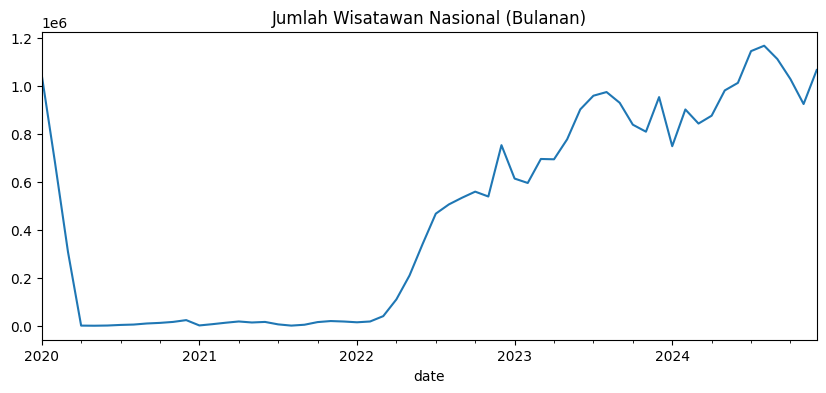

In [11]:
import matplotlib.pyplot as plt
ts.plot(title='Jumlah Wisatawan Nasional (Bulanan)', figsize=(10,4))
plt.show()

Data jumlah wisatawan nasional bulanan menunjukkan pola musiman tahunan (12 bulanan) yang terlihat jelas setelah periode pandemi yaitu setelah tahun 2021, sementara pada awal periode pengamatan pola musiman tidak tampak akibat gangguan COVID-19

## ACF PACF

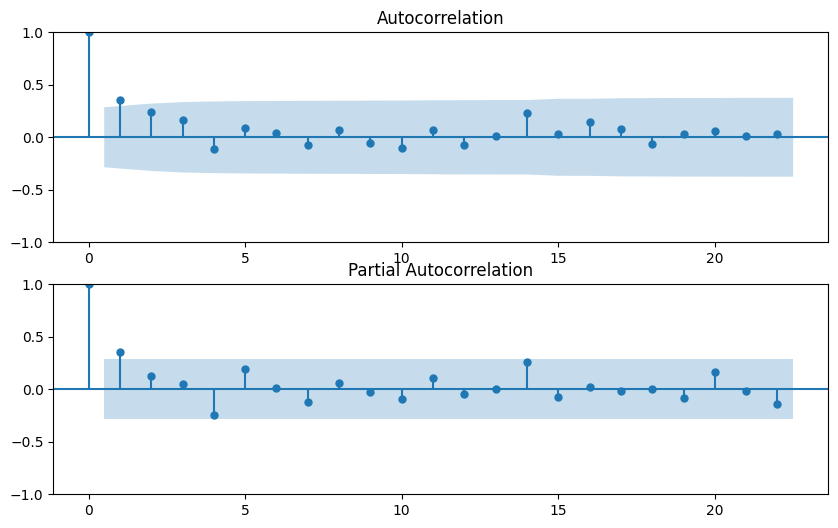

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts_diff_final = ts.diff().diff(12).dropna()

# Determine the maximum allowed lags
max_lags = len(ts_diff_final) // 2 - 1

fig, ax = plt.subplots(2,1, figsize=(10,6))
plot_acf(ts_diff_final, lags=max_lags, ax=ax[0])
plot_pacf(ts_diff_final, lags=max_lags, ax=ax[1])
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(ts.dropna())
print(f'ADF Statistic : {adf_result[0]}')
print(f'p-value       : {adf_result[1]}')

ADF Statistic : -0.9504007901806532
p-value       : 0.7709221822254391


In [14]:
ts_diff1 = ts.diff().dropna()

adf_result = adfuller(ts_diff1)
print('p-value diff1:', adf_result[1])

p-value diff1: 3.006189178520132e-07


In [15]:
ts_diff_seasonal = ts.diff(12).dropna()

adf_result = adfuller(ts_diff_seasonal)
print('p-value seasonal diff:', adf_result[1])

p-value seasonal diff: 0.778122866745061


## differencing d=1 D=1 s=12

In [16]:
ts_diff_final = ts.diff().diff(12).dropna()

adf_result = adfuller(ts_diff_final)
print('p-value final diff:', adf_result[1])

p-value final diff: 7.742386491384802e-08


# SARIMA Kombinasi Orde Manual

## model sarima(1,1,1)(1,1,1)12

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarima = model_sarima.fit()
print(result_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Wisatawan   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1493.845
Date:                            Sat, 03 Jan 2026   AIC                           2997.691
Time:                                    17:21:52   BIC                           3005.173
Sample:                                01-01-2020   HQIC                          3000.208
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6175   3.51e+15   1.76e-16      1.000   -6.87e+15    6.87e+15
ma.L1         -0.7965    1.2e+15  -

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Diagnostik SARIMA(1,1,1)(1,1,1)12

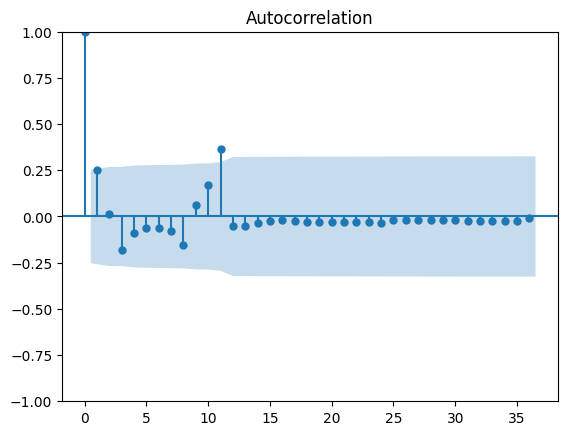

In [18]:
resid_sarima = result_sarima.resid

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(resid_sarima.dropna(), lags=36)
plt.show()

SARIMA (1,1,1)(1,1,1)12 tidak signfikan, hanya signifikan di Q dan baik ljung box(0.4)>0.05 dan masih ada lag yang signifikan sehingga model masih belum bagus

## SARIMA(0,1,1)(0,1,1,12)

In [19]:
model = SARIMAX(
    ts,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Wisatawan   No. Observations:                   60
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1488.758
Date:                            Sat, 03 Jan 2026   AIC                           2983.516
Time:                                    17:21:53   BIC                           2988.006
Sample:                                01-01-2020   HQIC                          2985.027
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1789    541.605     -0.000      1.000   -1061.705    1061.347
ma.S.L12   -2.133e+14   9.39e+04  -

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## SARIMA(1,1,0)(0,1,1,12)

In [20]:
model = SARIMAX(
    ts,
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
print(result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            Wisatawan   No. Observations:                   60
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood               -1541.976
Date:                              Sat, 03 Jan 2026   AIC                           3089.952
Time:                                      17:21:53   BIC                           3094.531
Sample:                                  01-01-2020   HQIC                          3091.514
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3757      0.050      7.456      0.000       0.277       0.474
ma.S.L12   -2.133e+

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## SARIMA(0,1,1)(1,1,0,12)

In [21]:
model = SARIMAX(
    ts,
    order=(0,1,1),
    seasonal_order=(1,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit()
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           Wisatawan   No. Observations:                   60
Model:             SARIMAX(0, 1, 1)x(1, 1, [], 12)   Log Likelihood                -446.335
Date:                             Sat, 03 Jan 2026   AIC                            898.671
Time:                                     17:21:53   BIC                            903.337
Sample:                                 01-01-2020   HQIC                           900.281
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0641      0.112     -0.571      0.568      -0.284       0.156
ar.S.L12      -0.0458      

SARIMA(0,1,1)(1,1,0,12) lebih baik waktu di search parameter sederhana karena :

1.   AIC jauh lebih kecil
2.   Ljung-Box p-value = 0.91 tidak autocorrelated
3.   JB p-value = 0.47 (cukup normal)


## SARIMA PDARIMA Auto Search pdarima

### Split Train(2020-2023), Test(2024)

In [22]:
import pandas as pd

X = pd.DataFrame(
    data=0,
    index=ts.index,
    columns=['kebijakan_perjalanan']
)
X.loc['2020-03':'2021-12', 'kebijakan_perjalanan'] = 1

train_end = '2023-12'

y_train = ts.loc[:train_end]
y_test  = ts.loc['2024-01':]

X_train = X.loc[:train_end]
X_test  = X.loc['2024-01':]

In [23]:
!pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(
    ts,
    seasonal=True,
    m=12,
    d=1,
    D=1,
    start_p=0, start_q=0,
    max_p=2, max_q=2,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.2 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1232.045, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1228.367, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1240.475, Time=0.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1235.699, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1229.421, Time=0.24 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.49 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1227.188, Time=0.16 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=1228.670, Time=0.32 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=1.33 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1240.456, Time=0.07 sec
 ARIMA(2,1,0)(0,1,1)[12]             : AIC=1232.501, Time=0.27 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1237.477, Time=0.27 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=inf, Time=0.95 sec
 ARIMA(1,1,0)(0,1,1)

Berdasarkan identifikasi musiman, uji ADF, analisis ACF–PACF, serta validasi menggunakan auto-ARIMA, model SARIMA(1,1,0)(0,1,1,12) dipilih sebagai model terbaik karena memiliki nilai AIC terendah dan parameter yang stabil.

### Fit SARIMA PDARIMA

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    y_train,                 # SAMA dengan SARIMAX
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarima = model_sarima.fit()
print(result_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            Wisatawan   No. Observations:                   48
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -280.719
Date:                              Sat, 03 Jan 2026   AIC                            567.439
Time:                                      17:22:05   BIC                            570.712
Sample:                                  01-01-2020   HQIC                           568.210
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1531      0.178      0.861      0.389      -0.196       0.502
ma.S.L12      -0.04

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [25]:
pred_sarima = result_sarima.get_forecast(steps=len(y_test))
y_pred_sarima = pred_sarima.predicted_mean

### Evaluasi SARIMA PDARIMA

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse_sarima = np.sqrt(mean_squared_error(y_test, y_pred_sarima))
mae_sarima  = mean_absolute_error(y_test, y_pred_sarima)
mape_sarima = mean_absolute_percentage_error(y_test, y_pred_sarima)

rmse_sarima, mae_sarima, mape_sarima

(np.float64(61383.81961772197), 48172.593678844896, 0.051402057124591505)

### Resid Train SARIMA

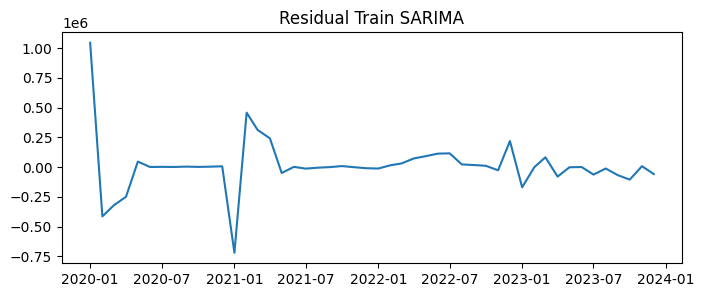

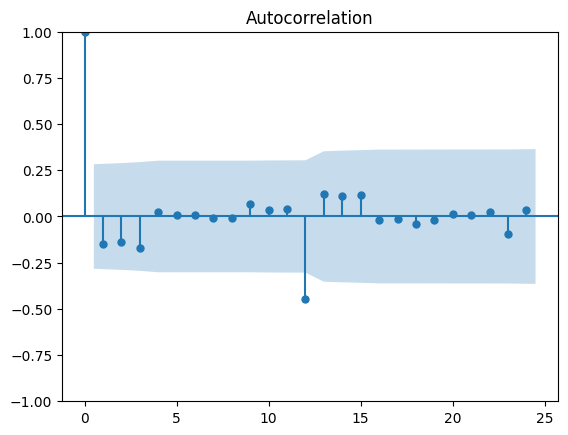

,lb_stat,lb_pvalue
12,17.528258,0.130783


In [27]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
resid_sarima_train = result_sarima.resid
plt.figure(figsize=(8,3))
plt.plot(resid_sarima_train)
plt.title("Residual Train SARIMA")
plt.show()

plot_acf(resid_sarima_train.dropna(), lags=24)
plt.show()

acorr_ljungbox(resid_sarima_train.dropna(), lags=[12], return_df=True)

### QQ Plot dan Histogram SARIMA RESID

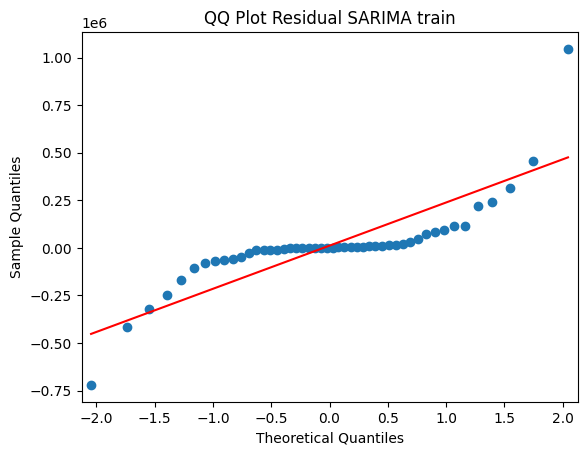

In [28]:
import statsmodels.api as sm

sm.qqplot(resid_sarima_train, line='s')
plt.title("QQ Plot Residual SARIMA train")
plt.show()

lag signifikan di lag 12, Satu spike musiman ≠ residual tidak white noise

p-value = 0.1308  (> 0.05)

Gagal menolak H0 → residual tidak memiliki autokorelasi signifikan

Berdasarkan analisis residual pelatihan, model SARIMA menunjukkan residual yang berfluktuasi di sekitar nol dan tidak memiliki autokorelasi signifikan berdasarkan uji Ljung–Box (p-value > 0.05). Meskipun terdapat spike pada lag musiman, pola tersebut tidak bersifat sistematis sehingga residual dapat dianggap mendekati white noise.

In [29]:
sarima_forecast = result_sarima.get_forecast(steps=len(y_test))
y_pred_sarima = sarima_forecast.predicted_mean

### Forecast SARIMA(test)

### Residual Test SARIMA

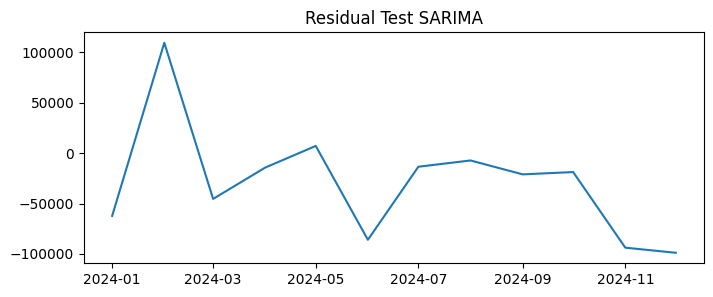

In [30]:
resid_sarima_test = y_test - y_pred_sarima
plt.figure(figsize=(8,3))
plt.plot(resid_sarima_test)
plt.title("Residual Test SARIMA")
plt.show()

Residual test TIDAK dipakai untuk uji white noise,
tapi untuk indikasi keterbatasan model prediksi.

# SARIMAX PDARIMA (X = kebijakan pembatasan perjalanan)

data dummy(mirip munit excel)

Kondisi normal	= 0

Pembatasan perjalanan	 = 1

In [31]:
ts

,Wisatawan
date,
2020-01-01,1045413
2020-02-01,684487
2020-03-01,307964
2020-04-01,1276
2020-05-01,805
2020-06-01,1602
2020-07-01,4099
2020-08-01,5652
2020-09-01,10126


### Buat X

In [32]:
ts.index = pd.to_datetime(ts.index)
ts.index

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
      

In [33]:
import pandas as pd

X = pd.DataFrame(
    data=0,
    index=ts.index,
    columns=['kebijakan_perjalanan']
)
X.loc['2020-03':'2021-12', 'kebijakan_perjalanan'] = 1

In [34]:
train_end = '2023-12'

y_train = ts.loc[:train_end]
y_test  = ts.loc['2024-01':]

X_train = X.loc[:train_end]
X_test  = X.loc['2024-01':]

In [35]:
X_train.index.equals(y_train.index)

True

### Fit SARIMAX

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    y_train,
    exog=X_train[['kebijakan_perjalanan']],
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarimax = model_sarimax.fit()
print(result_sarimax.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            Wisatawan   No. Observations:                   48
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -277.799
Date:                              Sat, 03 Jan 2026   AIC                            563.599
Time:                                      17:22:07   BIC                            567.963
Sample:                                  01-01-2020   HQIC                           564.627
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
kebijakan_perjalanan -1.791e+05   1.68e+05     -1.066      0.286   -5.08e+05  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [37]:
pred = result_sarimax.get_forecast(
    steps=len(y_test),
    exog=X_test
)

y_pred = pred.predicted_mean

### Evaluasi SARIMAX PDARIMA

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_pred))
mae_sarimax  = mean_absolute_error(y_test, y_pred)
mape_sarimax = mean_absolute_percentage_error(y_test, y_pred)

rmse_sarimax, mae_sarimax, mape_sarimax

(np.float64(56599.62356961536), 41656.900486657105, 0.044191964534733584)

### Resid Train SARIMAX

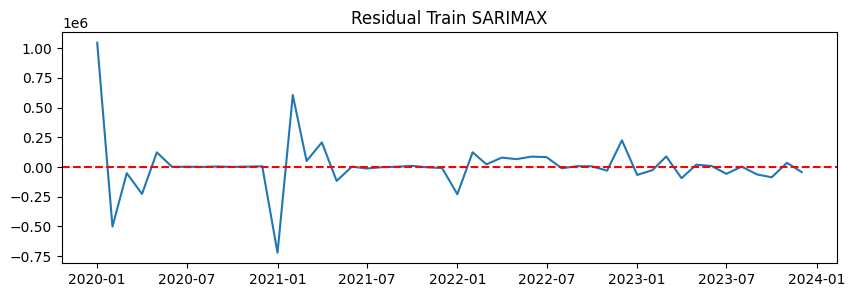

In [39]:
resid_sarimax_train = result_sarimax.resid.dropna()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(resid_sarimax_train)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Train SARIMAX")
plt.show()

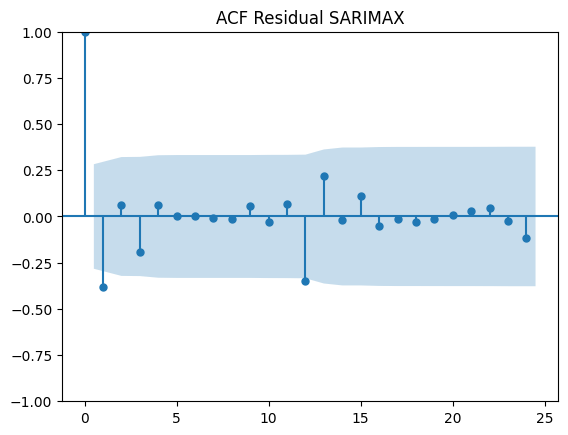

In [40]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(resid_sarimax_train, lags=24)
plt.title("ACF Residual SARIMAX")
plt.show()

lag signifikan di 1 dan 12

In [41]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(resid_sarimax_train, lags=[12], return_df=True)

,lb_stat,lb_pvalue
12,18.564938,0.099583


Hasil uji Ljung–Box pada residual model SARIMAX hingga lag ke-12 menghasilkan nilai p-value sebesar 0,099 (>0,05), sehingga tidak terdapat autokorelasi residual yang signifikan. Dengan demikian, residual dapat dianggap mendekati white noise dan model SARIMAX dinyatakan layak digunakan untuk peramalan.

### QQ Plot SARIMAX Resid

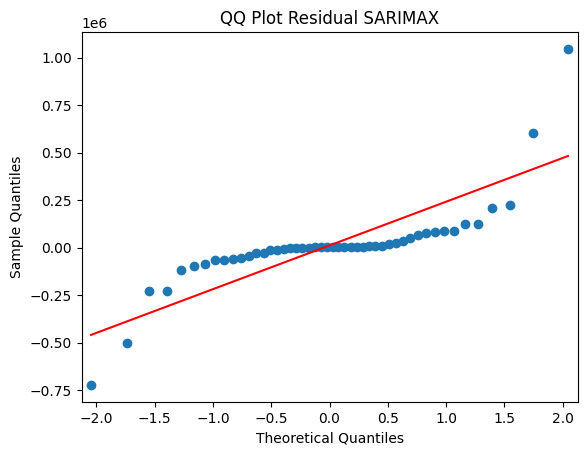

In [42]:
import statsmodels.api as sm

sm.qqplot(resid_sarimax_train, line='s')
plt.title("QQ Plot Residual SARIMAX")
plt.show()

### Forecast Test Resid SARIMAX

In [43]:
sarimax_forecast = result_sarimax.get_forecast(
    steps=len(y_test),
    exog=X_test
)
y_pred_sarimax = sarimax_forecast.predicted_mean

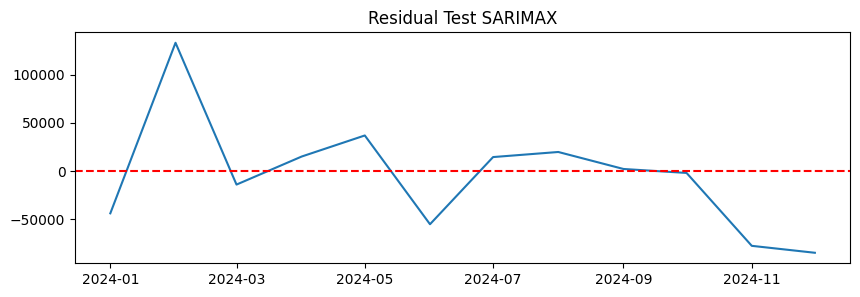

In [44]:
resid_sarimax_test = y_test - y_pred_sarimax
plt.figure(figsize=(10,3))
plt.plot(resid_sarimax_test)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Test SARIMAX")
plt.show()

# Hybrid I SARIMAX + AR Residual SARIMAX Train

In [45]:
from statsmodels.tsa.arima.model import ARIMA

resid_model = ARIMA(resid_sarimax_train, order=(1,0,0))
resid_result = resid_model.fit()

print(resid_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -657.960
Date:                Sat, 03 Jan 2026   AIC                           1321.920
Time:                        17:22:09   BIC                           1327.533
Sample:                    01-01-2020   HQIC                          1324.041
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.167e+04   1.23e+04      0.945      0.345   -1.25e+04    3.59e+04
ar.L1         -0.6440      0.032    -20.302      0.000      -0.706      -0.582
sigma2       2.34e+10      0.034   6.85e+11      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Prediksi Residual dengan data test asli

In [46]:
resid_forecast = resid_result.forecast(steps=len(y_test))
resid_forecast

,predicted_mean
2024-01-01,47108.109331
2024-02-01,-11159.253333
2024-03-01,26363.664976
2024-04-01,2199.719088
2024-05-01,17760.776362
2024-06-01,7739.792844
2024-07-01,14193.088973
2024-08-01,10037.306174
2024-09-01,12713.540198
2024-10-01,10990.103508


### Peramalan Hybrid I

In [47]:
hybrid_forecast1 = sarimax_forecast.predicted_mean + resid_forecast
hybrid_forecast1

,predicted_mean
2024-01-01,8.395988e+05
2024-02-01,7.570436e+05
2024-03-01,8.832073e+05
2024-04-01,8.626536e+05
2024-05-01,9.616287e+05
2024-06-01,1.075330e+06
2024-07-01,1.144223e+06
2024-08-01,1.157216e+06
2024-09-01,1.122253e+06
2024-10-01,1.040950e+06


### Evaluasi Hybrid I

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def eval_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    return rmse, mae, mape

# Evaluasi HYBRID
rmse_h, mae_h, mape_h = eval_metrics(
    y_test.values,
    hybrid_forecast1.values
)

rmse_h, mae_h, mape_h

(np.float64(66504.5753775612),
 49258.46046310699,
 np.float64(0.05375833168968932))

### Resid Hybrid I

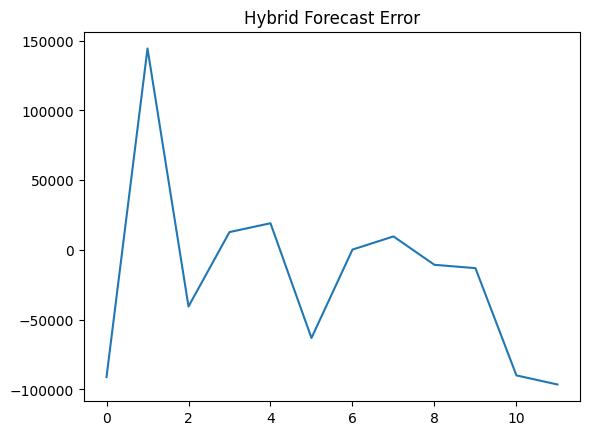

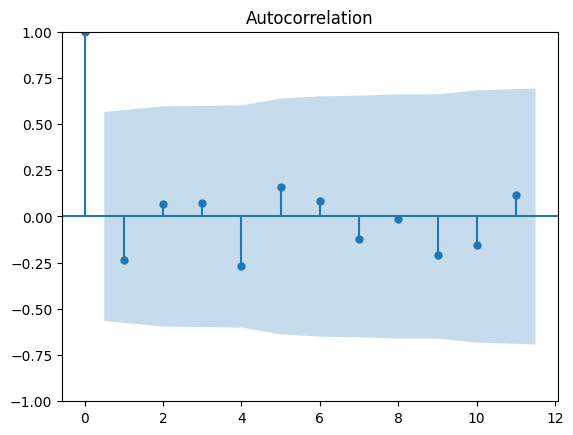

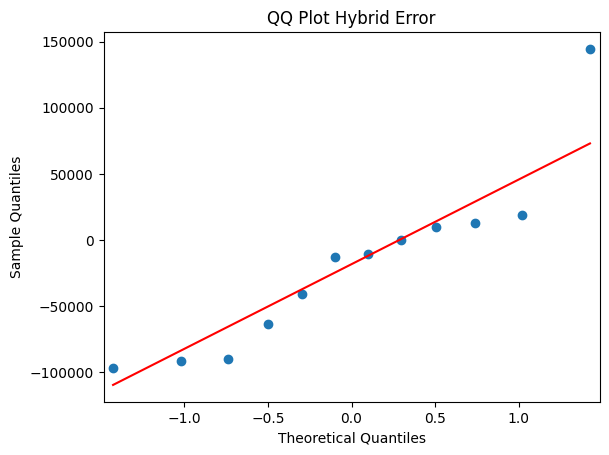

In [49]:
hybrid_error = y_test.values - hybrid_forecast1.values

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Time plot
plt.plot(hybrid_error)
plt.title("Hybrid Forecast Error")
plt.show()

# ACF
sm.graphics.tsa.plot_acf(hybrid_error, lags=len(hybrid_error) - 1)
plt.show()

# QQ plot
sm.qqplot(hybrid_error, line='s')
plt.title("QQ Plot Hybrid Error")
plt.show()

# Hybrid II: SARIMA + Residual SARIMA

In [50]:
from statsmodels.tsa.arima.model import ARIMA

resid_model2 = ARIMA(resid_sarima_train, order=(1,0,0))
resid_result2 = resid_model2.fit()

print(resid_result2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -663.469
Date:                Sat, 03 Jan 2026   AIC                           1332.938
Time:                        17:22:10   BIC                           1338.551
Sample:                    01-01-2020   HQIC                          1335.059
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.166e+04   1.75e+04      0.667      0.505   -2.26e+04    4.59e+04
ar.L1         -0.2534      0.065     -3.923      0.000      -0.380      -0.127
sigma2      2.866e+10      0.025   1.15e+12      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [51]:
resid_sarima_train

,0
date,
2020-01-01,1.045413e+06
2020-02-01,-4.142864e+05
2020-03-01,-3.212638e+05
2020-04-01,-2.490386e+05
2020-05-01,4.648621e+04
2020-06-01,8.700644e+02
2020-07-01,2.374975e+03
2020-08-01,1.170690e+03
2020-09-01,4.236217e+03


### forecast SARIMA pada periode TEST

In [52]:
resid_forecast2 = resid_result2.forecast(steps=len(y_test))
resid_forecast2

,predicted_mean
2024-01-01,29441.616215
2024-02-01,7157.637661
2024-03-01,12803.953471
2024-04-01,11373.289636
2024-05-01,11735.791323
2024-06-01,11643.940624
2024-07-01,11667.213760
2024-08-01,11661.316811
2024-09-01,11662.810980
2024-10-01,11662.432388


### Peramalan Hybrid

In [53]:
hybrid_forecast2 = y_pred_sarima + resid_forecast2
hybrid_forecast2

,predicted_mean
2024-01-01,8.401928e+05
2024-02-01,7.990687e+05
2024-03-01,9.009376e+05
2024-04-01,9.011464e+05
2024-05-01,9.853597e+05
2024-06-01,1.109872e+06
2024-07-01,1.169638e+06
2024-08-01,1.185852e+06
2024-09-01,1.144351e+06
2024-10-01,1.058349e+06


### Evaluasi Hybrid II

In [54]:
rmse_h2, mae_h2, mape_h2 = eval_metrics(
    y_test.values,
    hybrid_forecast2.values
)

rmse_h2, mae_h2, mape_h2

(np.float64(70029.08226229818),
 58632.555707763735,
 np.float64(0.06257350106085693))

### Resid Hybrid II

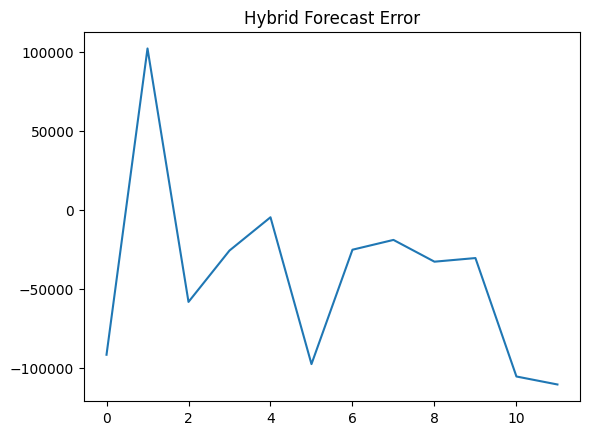

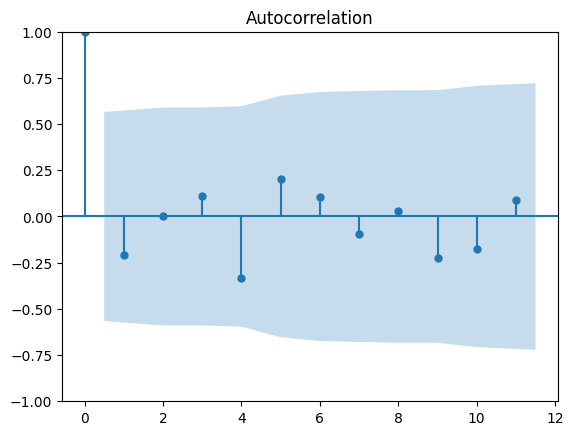

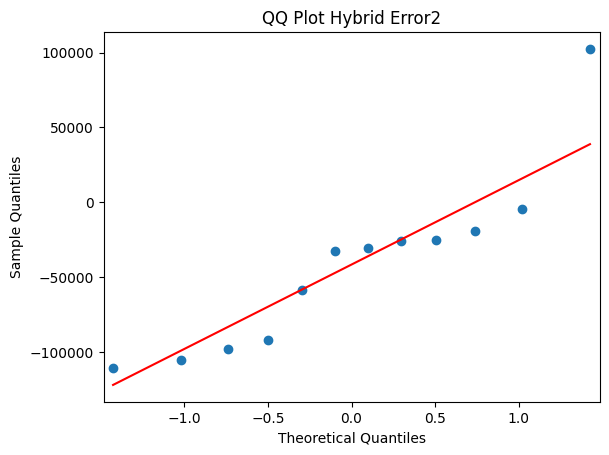

In [55]:
hybrid_error2 = y_test.values - hybrid_forecast2.values

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Time plot
plt.plot(hybrid_error2)
plt.title("Hybrid Forecast Error")
plt.show()

# ACF
sm.graphics.tsa.plot_acf(hybrid_error2, lags=len(hybrid_error2) - 1)
plt.show()

# QQ plot
sm.qqplot(hybrid_error2, line='s')
plt.title("QQ Plot Hybrid Error2")
plt.show()

# Hybrid III: SARIMAX + Residual SARIMA

In [56]:
from statsmodels.tsa.arima.model import ARIMA

resid_model3 = ARIMA(resid_sarima_train, order=(1,0,0))
resid_result3 = resid_model3.fit()

print(resid_result3.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -663.469
Date:                Sat, 03 Jan 2026   AIC                           1332.938
Time:                        17:22:11   BIC                           1338.551
Sample:                    01-01-2020   HQIC                          1335.059
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.166e+04   1.75e+04      0.667      0.505   -2.26e+04    4.59e+04
ar.L1         -0.2534      0.065     -3.923      0.000      -0.380      -0.127
sigma2      2.866e+10      0.025   1.15e+12      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Forecast

In [57]:
resid_forecast3 = resid_result3.forecast(steps=len(y_test))
resid_forecast3

,predicted_mean
2024-01-01,29441.616215
2024-02-01,7157.637661
2024-03-01,12803.953471
2024-04-01,11373.289636
2024-05-01,11735.791323
2024-06-01,11643.940624
2024-07-01,11667.213760
2024-08-01,11661.316811
2024-09-01,11662.810980
2024-10-01,11662.432388


### Peramalan Hybrid III

In [58]:
hybrid_forecast3 = y_pred_sarimax + resid_forecast3
hybrid_forecast3

,predicted_mean
2024-01-01,8.219323e+05
2024-02-01,7.753605e+05
2024-03-01,8.696476e+05
2024-04-01,8.718272e+05
2024-05-01,9.556037e+05
2024-06-01,1.079234e+06
2024-07-01,1.141697e+06
2024-08-01,1.158840e+06
2024-09-01,1.121202e+06
2024-10-01,1.041623e+06


### Evaluasi Hybrid III

In [59]:
rmse_h3, mae_h3, mape_h3 = eval_metrics(
    y_test.values,
    hybrid_forecast3.values
)

rmse_h3, mae_h3, mape_h3

(np.float64(61149.68192315017),
 45223.107762162756,
 np.float64(0.048743268477523936))

### Resid Hybrid III

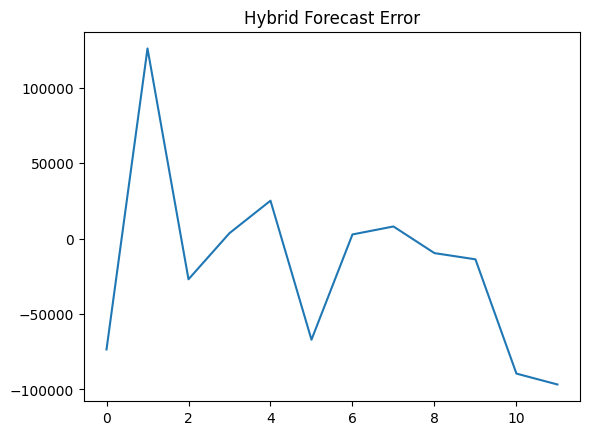

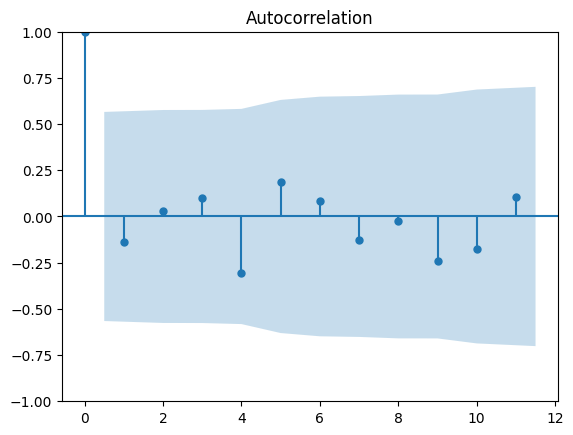

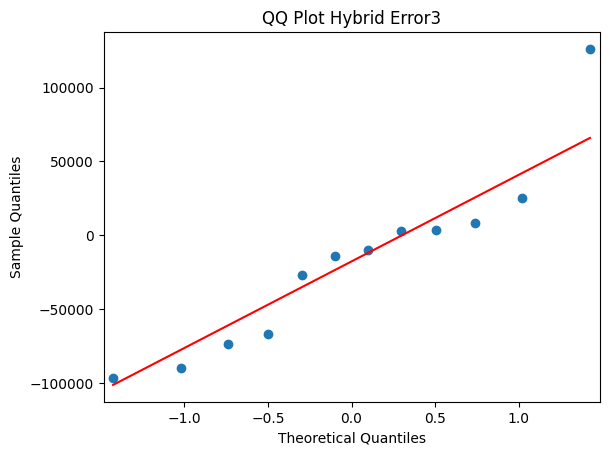

In [60]:
hybrid_error3 = y_test.values - hybrid_forecast3.values

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Time plot
plt.plot(hybrid_error3)
plt.title("Hybrid Forecast Error")
plt.show()

# ACF
sm.graphics.tsa.plot_acf(hybrid_error3, lags=len(hybrid_error3) - 1)
plt.show()

# QQ plot
sm.qqplot(hybrid_error3, line='s')
plt.title("QQ Plot Hybrid Error3")
plt.show()

# Hybrid IV: SARIMAX + NN (LSTM / MLP)

SAMA PERSIS seperti Hybrid III
Gunakan sarimax_result, y_pred_sarimax, dan resid_sarimax_train

#### Noted NN

Alurnya:

SARIMAX
→ menangkap tren, musiman, dan pengaruh kebijakan (X) secara linear & statistik

Residual SARIMAX
→ sisa error yang tidak tertangkap SARIMAX

Neural Network
→ belajar pola non-linear dari residual

Hybrid Forecast
→ SARIMAX forecast + NN residual forecast

Secara matematis:

𝑦𝑡=𝑦^𝑡𝑆𝐴𝑅𝐼𝑀𝐴𝑋 + 𝑒^𝑡𝑁𝑁

	​


### SIAPKAN DATA RESIDUAL UNTUK NN

#### Bentuk supervised (lag features)

In [61]:
import pandas as pd

def make_lagged(series, n_lags=12):
    df = pd.DataFrame(series)
    for i in range(1, n_lags+1):
        df[f"lag_{i}"] = df[0].shift(i)
    df.dropna(inplace=True)
    return df

resid_df = make_lagged(resid_sarimax_train, n_lags=12)

X_nn = resid_df.drop(columns=0)
y_nn = resid_df[0]

### SPLIT TRAIN–TEST UNTUK NN (INTERNAL)

In [62]:
split_idx = int(len(X_nn) * 0.8)

X_nn_train = X_nn.iloc[:split_idx]
X_nn_test  = X_nn.iloc[split_idx:]

y_nn_train = y_nn.iloc[:split_idx]
y_nn_test  = y_nn.iloc[split_idx:]

### TRAIN NEURAL NETWORK (MLP)

In [63]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

nn_model.fit(X_nn_train, y_nn_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=42)

### FORECAST RESIDUAL DENGAN NN (TEST HORIZON)

In [64]:
import numpy as np

last_window = resid_sarimax_train.iloc[-12:].values
nn_resid_forecast = []

for _ in range(len(y_test)):
    pred = nn_model.predict(last_window.reshape(1, -1))[0]
    nn_resid_forecast.append(pred)
    last_window = np.roll(last_window, -1)
    last_window[-1] = pred

nn_resid_forecast = pd.Series(
    nn_resid_forecast,
    index=y_test.index
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/valida

### HYBRID FORECAST NN

In [65]:
hybrid_forecast_nn = y_pred_sarimax + nn_resid_forecast
hybrid_forecast_nn

,0
2024-01-01,7.800311e+05
2024-02-01,8.094696e+05
2024-03-01,8.167309e+05
2024-04-01,8.724262e+05
2024-05-01,9.905454e+05
2024-06-01,1.095310e+06
2024-07-01,1.146623e+06
2024-08-01,1.172957e+06
2024-09-01,1.154281e+06
2024-10-01,1.061589e+06


### EVALUASI HYBRID NN (OUT-SAMPLE)

In [66]:
rmse_hnn, mae_hnn, mape_hnn = eval_metrics(
    y_test.values,
    hybrid_forecast_nn.values
)

rmse_hnn, mae_hnn, mape_hnn

(np.float64(64298.773716871896),
 46723.191296079596,
 np.float64(0.04803243915652139))

# Perbandingan Evaluasi All

In [67]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX", "HYBRID SARIMAX + AR RESID SARIMAX TRAIN", "HYBRID SARIMA + RESID SARIMA", "HYBRID SARIMAX + RESID SARIMA", "HYBRID SARIMAX + NN(MLP)"],
    "RMSE": [rmse_sarima, rmse_sarimax, rmse_h, rmse_h2, rmse_h3, rmse_hnn],
    "MAE":  [mae_sarima,  mae_sarimax,  mae_h, mae_h2, mae_h3, mae_hnn],
    "MAPE": [mape_sarima, mape_sarimax, mape_h, mape_h2, mape_h3, mape_hnn]
})

comparison

,Model,RMSE,MAE,MAPE
0,SARIMA,61383.819618,48172.593679,0.051402
1,SARIMAX,56599.623570,41656.900487,0.044192
2,HYBRID SARIMAX + AR RESID SARIMAX TRAIN,66504.575378,49258.460463,0.053758
3,HYBRID SARIMA + RESID SARIMA,70029.082262,58632.555708,0.062574
4,HYBRID SARIMAX + RESID SARIMA,61149.681923,45223.107762,0.048743
5,HYBRID SARIMAX + NN(MLP),64298.773717,46723.191296,0.048032


model bagus sarima, sarimax, HYBRID SARIMAX + Resid SARIMA

# Peramalan Total Wisatawan Bulanan

## SARIMA

### Prediksi Jangka Pendek (Evaluasi)

##### Model

In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima_full = SARIMAX(
    ts,
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarima_full = model_sarima_full.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


##### Forecast Jangka Pendek

In [69]:
sarima_short = result_sarima_full.get_forecast(steps=12)
sarima_short_mean = sarima_short.predicted_mean
sarima_short_mean

,predicted_mean
2025-01-01,8.604591e+05
2025-02-01,1.013117e+06
2025-03-01,9.542307e+05
2025-04-01,9.869565e+05
2025-05-01,1.092239e+06
2025-06-01,1.123683e+06
2025-07-01,1.255942e+06
2025-08-01,1.278369e+06
2025-09-01,1.223068e+06
2025-10-01,1.139364e+06


#### Plot Line Chart

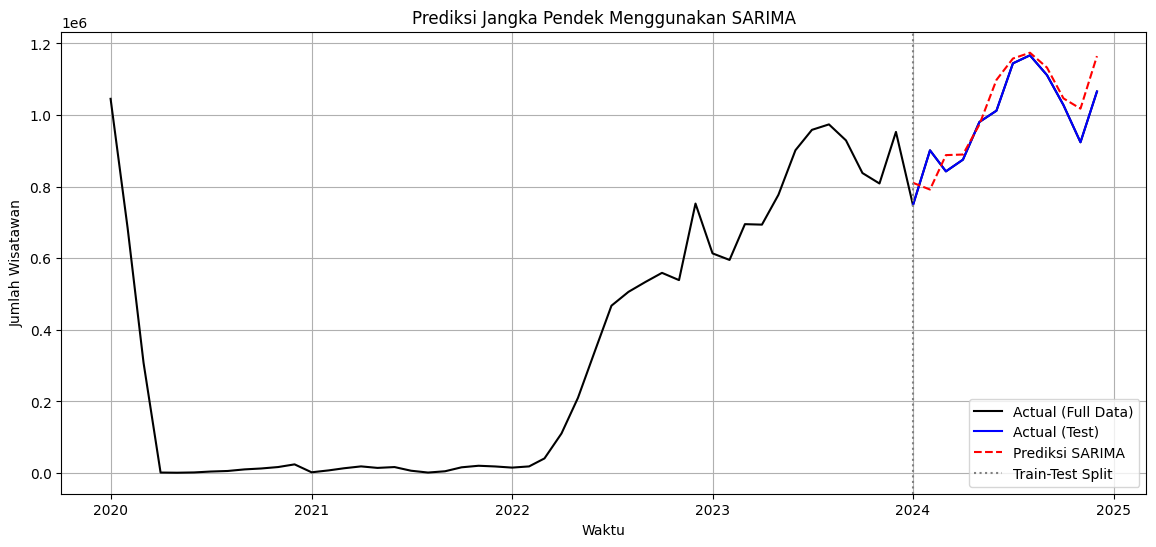

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Actual full
plt.plot(ts, label='Actual (Full Data)', color='black')

# Actual test
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    color='blue'
)

# Prediksi SARIMA
plt.plot(
    y_test.index,
    y_pred_sarima,
    label='Prediksi SARIMA',
    color='red',
    linestyle='--'
)

# Garis batas train-test
plt.axvline(
    y_test.index[0],
    color='gray',
    linestyle=':',
    label='Train-Test Split'
)

plt.title('Prediksi Jangka Pendek Menggunakan SARIMA')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

### Prediksi Jangka Panjang

In [71]:
sarima_final = SARIMAX(
    ts,
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [72]:
sarima_long = result_sarima_full.get_forecast(steps=24)
sarima_long_mean = sarima_long.predicted_mean
sarima_long_mean

,predicted_mean
2025-01-01,8.604591e+05
2025-02-01,1.013117e+06
2025-03-01,9.542307e+05
2025-04-01,9.869565e+05
2025-05-01,1.092239e+06
2025-06-01,1.123683e+06
2025-07-01,1.255942e+06
2025-08-01,1.278369e+06
2025-09-01,1.223068e+06
2025-10-01,1.139364e+06


SARIMA mempertahankan pola musiman tahunan, namun tidak mempertimbangkan faktor eksternal.

#### Plot Line Chart

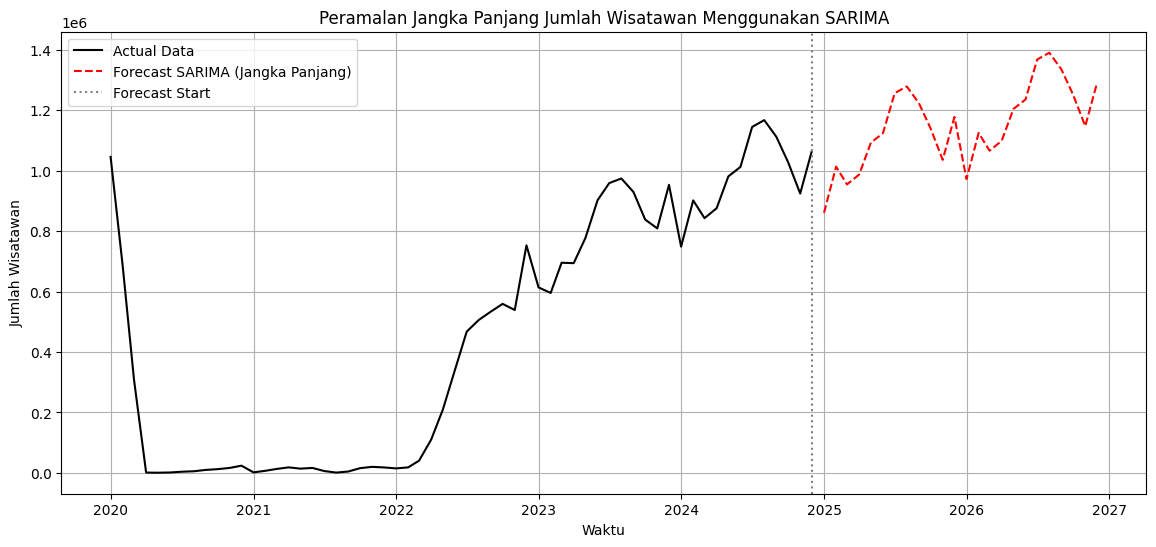

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Actual data
plt.plot(ts, label='Actual Data', color='black')

# Forecast SARIMA
plt.plot(
    sarima_long_mean.index,
    sarima_long_mean,
    label='Forecast SARIMA (Jangka Panjang)',
    color='red',
    linestyle='--'
)

plt.axvline(
    ts.index[-1],
    color='gray',
    linestyle=':',
    label='Forecast Start'
)

plt.title('Peramalan Jangka Panjang Jumlah Wisatawan Menggunakan SARIMA')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

## SARIMAX

### Prediksi Jangka Pendek

#### Model

In [74]:
future_index_12 = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(),
                                periods=12, freq='MS')
future_index_24 = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(),
                                periods=24, freq='MS')

X_future_12 = pd.DataFrame(
    0, index=future_index_12, columns=['kebijakan_perjalanan']
)

X_future_24 = pd.DataFrame(
    0, index=future_index_24, columns=['kebijakan_perjalanan']
)

In [75]:
model_sarimax_full = SARIMAX(
    ts,
    exog=X,
    order=(1,1,0),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarimax_full = model_sarimax_full.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Forecast Jangka Pendek

In [76]:
sarimax_short = result_sarimax_full.get_forecast(
    steps=12, exog=X_future_12
).predicted_mean

sarimax_short

,predicted_mean
2025-01-01,8.606788e+05
2025-02-01,1.013481e+06
2025-03-01,9.546669e+05
2025-04-01,9.874248e+05
2025-05-01,1.092720e+06
2025-06-01,1.124170e+06
2025-07-01,1.256431e+06
2025-08-01,1.278859e+06
2025-09-01,1.223559e+06
2025-10-01,1.139855e+06


#### Plot Line Chart

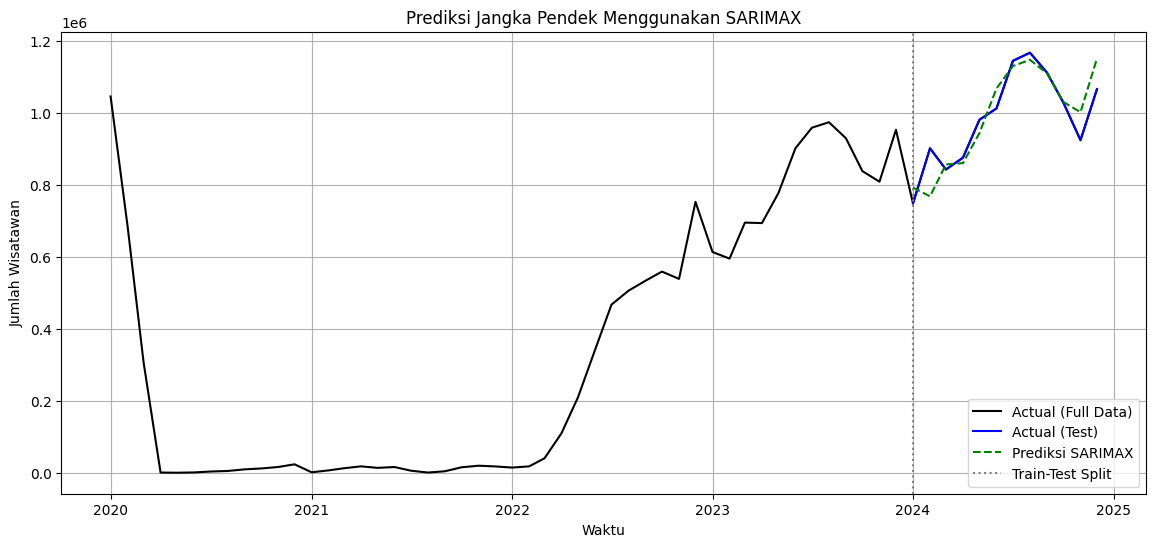

In [77]:
plt.figure(figsize=(14,6))

# Actual full
plt.plot(ts, label='Actual (Full Data)', color='black')

# Actual test
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    color='blue'
)

# Prediksi SARIMAX
plt.plot(
    y_test.index,
    y_pred_sarimax,
    label='Prediksi SARIMAX',
    color='green',
    linestyle='--'
)

# Garis batas train-test
plt.axvline(
    y_test.index[0],
    color='gray',
    linestyle=':',
    label='Train-Test Split'
)

plt.title('Prediksi Jangka Pendek Menggunakan SARIMAX')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

### Prediksi Jangka Panjang

In [78]:
sarimax_long_forecast_results = result_sarimax_full.get_forecast(
    steps=24, exog=X_future_24
)
sarimax_long_24_steps_mean = sarimax_long_forecast_results.predicted_mean
sarimax_long_24_steps_mean

,predicted_mean
2025-01-01,8.606788e+05
2025-02-01,1.013481e+06
2025-03-01,9.546669e+05
2025-04-01,9.874248e+05
2025-05-01,1.092720e+06
2025-06-01,1.124170e+06
2025-07-01,1.256431e+06
2025-08-01,1.278859e+06
2025-09-01,1.223559e+06
2025-10-01,1.139855e+06


SARIMAX mampu memberikan proyeksi yang lebih realistis karena mempertimbangkan pengaruh kebijakan perjalanan.

#### Plot Line Chart

In [79]:
sarimax_long_12_step_forecast = result_sarimax_full.get_forecast(
    steps=12,
    exog=X_future_12
)

sarimax_long_mean = sarimax_long_12_step_forecast.predicted_mean
sarimax_long_mean

,predicted_mean
2025-01-01,8.606788e+05
2025-02-01,1.013481e+06
2025-03-01,9.546669e+05
2025-04-01,9.874248e+05
2025-05-01,1.092720e+06
2025-06-01,1.124170e+06
2025-07-01,1.256431e+06
2025-08-01,1.278859e+06
2025-09-01,1.223559e+06
2025-10-01,1.139855e+06


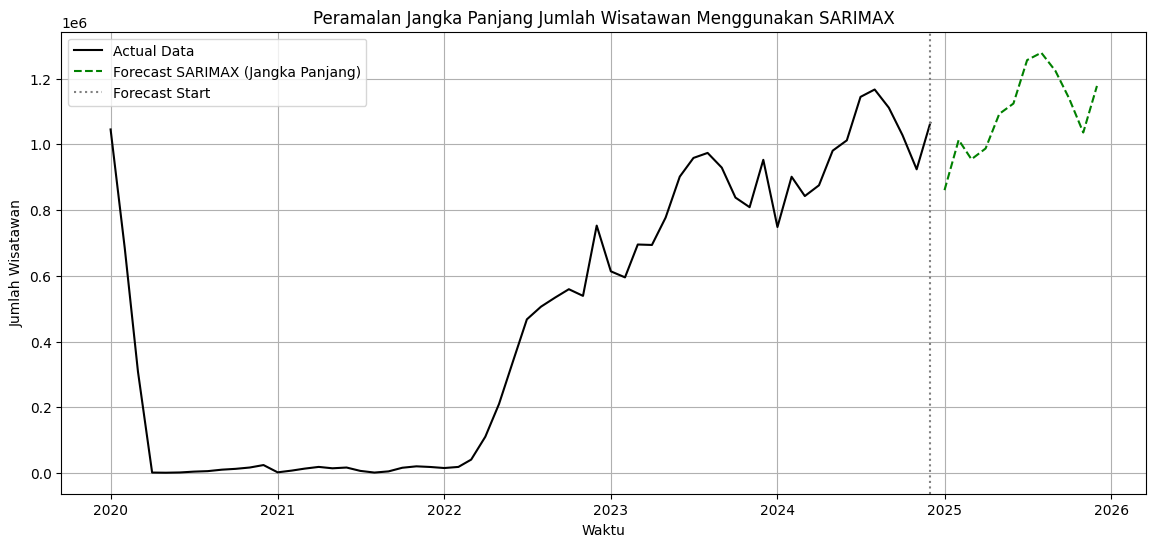

In [80]:
plt.figure(figsize=(14,6))

# Actual data
plt.plot(ts, label='Actual Data', color='black')

# Forecast SARIMAX
plt.plot(
    sarimax_long_mean.index,
    sarimax_long_mean,
    label='Forecast SARIMAX (Jangka Panjang)',
    color='green',
    linestyle='--'
)

plt.axvline(
    ts.index[-1],
    color='gray',
    linestyle=':',
    label='Forecast Start'
)

plt.title('Peramalan Jangka Panjang Jumlah Wisatawan Menggunakan SARIMAX')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

## HYBRID (SARIMAX + RESIDUAL SARIMA)

### Prediksi Jangka Pendek

In [81]:
resid_full = result_sarimax_full.resid.dropna()

In [82]:
import numpy as np

def make_lag(series, lag=12):
    X, y = [], []
    for i in range(lag, len(series)):
        X.append(series[i-lag:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X_r, y_r = make_lag(resid_full.values, lag=12)

In [83]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(32,16),
    max_iter=1000,
    random_state=42
)
mlp.fit(X_r, y_r)

MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)

#### Plot Line Chart

In [84]:
def forecast_resid_nn(model, last_resid, steps, lag=12):
    preds = []
    history = list(last_resid[-lag:])
    for _ in range(steps):
        x = np.array(history[-lag:]).reshape(1, -1)
        yhat = model.predict(x)[0]
        preds.append(yhat)
        history.append(yhat)
    return np.array(preds)

resid_short_nn = forecast_resid_nn(mlp, resid_full.values, 12)
resid_long_nn  = forecast_resid_nn(mlp, resid_full.values, 24)

In [85]:
hybrid_short = sarimax_short.values + resid_short_nn
hybrid_long  = sarimax_long_24_steps_mean.values + resid_long_nn

Hybrid mampu menangkap pola tambahan pada residual, namun peningkatan akurasi tidak selalu signifikan dibandingkan model utama.

#### Plot Line Chart

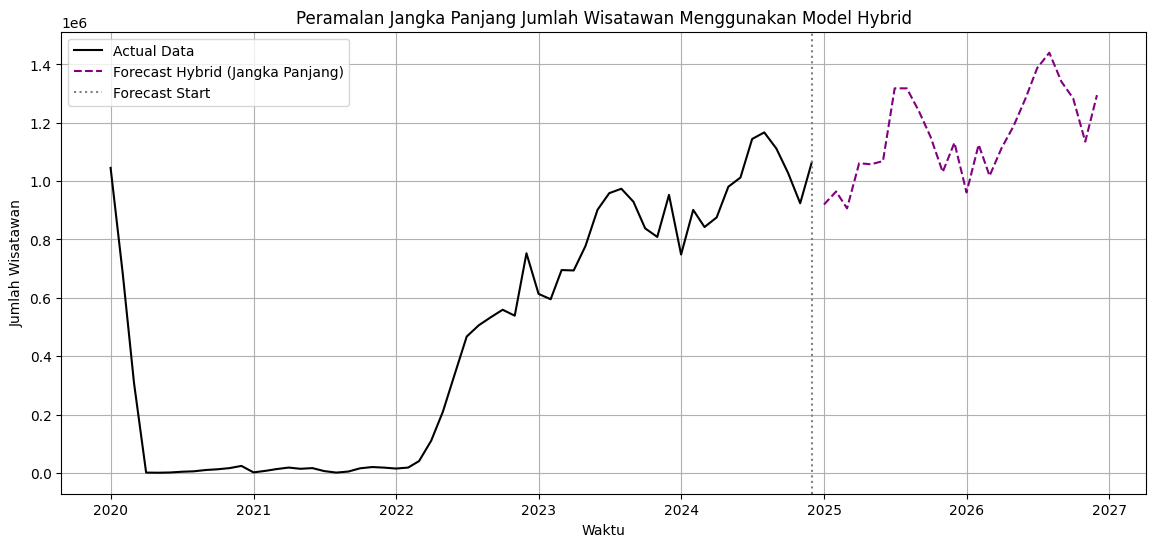

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert hybrid_long (ndarray) to a Series with the correct index for plotting
hybrid_long_series = pd.Series(hybrid_long, index=sarimax_long_24_steps_mean.index)

plt.figure(figsize=(14,6))

# Actual data
plt.plot(
    ts,
    label='Actual Data',
    color='black'
)

# Forecast Hybrid
plt.plot(
    hybrid_long_series.index,
    hybrid_long_series,
    label='Forecast Hybrid (Jangka Panjang)',
    color='purple',
    linestyle='--'
)

plt.axvline(
    ts.index[-1],
    color='gray',
    linestyle=':',
    label='Forecast Start'
)

plt.title('Peramalan Jangka Panjang Jumlah Wisatawan Menggunakan Model Hybrid')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.grid(True)
plt.show()

##

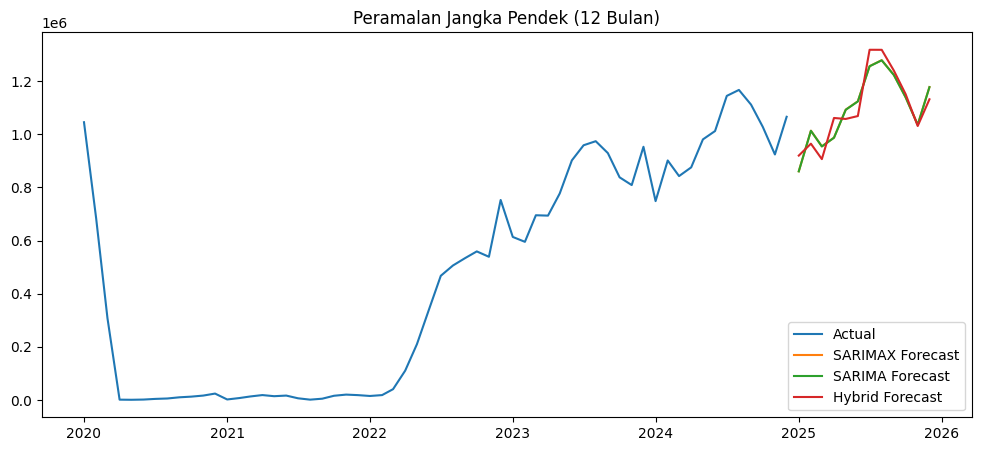

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts, label='Actual')
plt.plot(sarimax_short, label='SARIMAX Forecast')
plt.plot(sarima_short_mean, label='SARIMA Forecast')
plt.plot(sarimax_short.index, hybrid_short, label='Hybrid Forecast')
plt.legend()
plt.title('Peramalan Jangka Pendek (12 Bulan)')
plt.show()

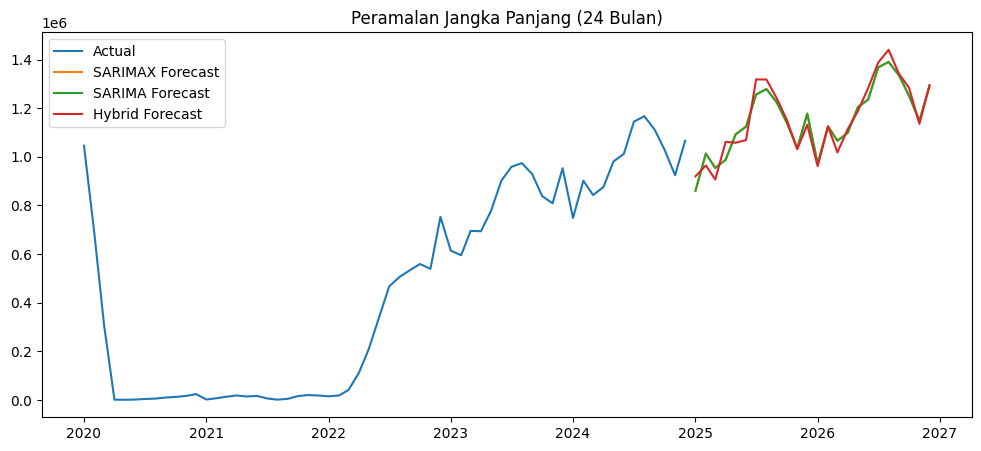

In [88]:
plt.figure(figsize=(12,5))
plt.plot(ts, label='Actual')
plt.plot(sarimax_long_24_steps_mean, label='SARIMAX Forecast')
plt.plot(sarima_long_mean, label='SARIMA Forecast')
plt.plot(sarimax_long_24_steps_mean.index, hybrid_long, label='Hybrid Forecast')
plt.legend()
plt.title('Peramalan Jangka Panjang (24 Bulan)')
plt.show()